# Notebook for Examining Data Quality and Data Drifts

## Import Functions

In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.ndimage import gaussian_filter1d

import trxrd

%matplotlib widget

## Define Experimental Parameters

In [2]:
# Experimental Parameters and Defaults

# ============================================================
# Data and Mask Paths, Scan Name, and Filename Pattern
# ============================================================
DATA_PATH = Path(r"\\s7data\beams46\7IDC\Cotts\2025_11Exp\BTO400_S3") # Path to directory containing TIFF files
MASK_FILE = Path(r"C:\Users\lheald\Documents\Guzelturk_Lab\TRXRDPython\testdata\mask_2021_dec.tif") # Path to mask file
SCAN_NAME = "BTO400nmS3_360Kre4" # Prefix in file name to identify relevant files, e.g. "550nm_re" etc.
SCAN_TYPE = "delay_scan" # Type of scan based on filename pattern, e.g. "delay_scan", "theta_samz", etc. Must correspond to a key in the "filename_patterns" dictionary in trxrd.py
BACKGROUND_PATH = Path(r"\\s7data\beams46\7IDC\Cotts\2025_11Exp\BlankSubstratePinkBeam\blanksubstratePinkBeam285K-1.0fshw-4e-09delay00004_045.tif")
SAVE_PATH = Path(r"C:\Users\lheald\Documents\Guzelturk_Lab\Cotts_Processed_Data\BTO400nmS3_360Kre4\repo") # Path to directory where processed data will be saved, e.g. as .h5 file

# ============================================================
# General Defaults
# ============================================================
FIGSIZE = (10, 4)
STD_FACTOR = 3
MAX_PROCESSORS = 4
DELAY_SIGN = -1 # Check file naming scheme, sometimes positives delays have "-" in front and negative have no sign so need to invert sign

# ============================================================
# Beam Stop Mask Defaults
# ============================================================
MASK_CENTER_X = 52
MASK_CENTER_Y = 1667
MASK_RADIUS = 30

# ============================================================
# Center Guess and Sampling Defaults
# ============================================================
CENTER_X = 44
CENTER_Y = 1666
DOWNSAMPLE = 2 # Downsample factor for center finding, e.g. 2 means use every other pixel, 4 means use every 4th pixel, etc.

# ============================================================
# Detector Parameters and Defaults
# ============================================================
# PONI file from pyFAI-calib2. Set to a Path to use PONI geometry;
# set to None to use the manual parameters below.
PONI_FILE = Path(r"C:\Users\lheald\Documents\Guzelturk_Lab\Cotts_Processed_Data\CeO2\low_keV\CeO2_poni.poni")                 # Path to .poni file, or None
# Detector and beam parameters
PIXEL1 = 1.72e-4                 # m, detector pixel size along rows (y)
PIXEL2 = 1.72e-4                 # m, detector pixel size along cols (x)
DISTANCE = 0.1723                 # m, sample-to-detector distance
WAVELENGTH = 0.39738514824147314e-10          # m

# Detector orientation
TILT_ANGLE = np.deg2rad(0)               # rad
TILT_PLANE_ROTATION = np.deg2rad(90)      # rad
ROT3 = 0.0                      # rad, in-plane detector rotation

# Optional corrections
POLARIZATION_FACTOR = 0.999      # e.g. 0.99 or None
DARK = None                     # 2D dark image or None
FLAT = None                     # 2D flat-field image or None

# ============================================================
# Azimuthal Averaging and Normalization Defaults
# ============================================================
UNIT = "q_A^-1" # Unit for x-axis of azimuthally averaged data, e.g. "q_A^-1" for inverse Angstroms, "2theta_deg" for degrees, etc. 
NAN_MIN = 0.35 # Minimum value for valid data, values below this will be set to NaN, e.g. 0.35 or None for no minimum threshold
NAN_MAX = None # Maximum value for valid data, values above this will be set to NaN, e.g. 1.0 or None for no maximum threshold
NORM_MIN = 4.05 # Minimum value for normalization, values below this will be set to this value before normalization, e.g. 0.5 or None for no minimum threshold
NORM_MAX = 4.25 # Maximum value for normalization, values above this will be set to this value before normalization, e.g. 1.0 or None for no maximum threshold
N_POINTS = 3000 # Number of points for azimuthal averaging, e.g. 3000 or None to use all pixels

# ============================================================
# Background Subtraction Defaults
# ============================================================
BACKGROUND_NORM_MIN = 1.0 # Minimum value for background normalization, values below this will be set to this value before normalization, e.g. 0.5 or None for no minimum threshold
BACKGROUND_NORM_MAX = 1.5 # Maximum value for background normalization, values above this will be set to this value before normalization, e.g. 1.0 or None for no maximum threshold

# ============================================================
# Baseline Subtraction Defaults
# ============================================================
LAM_VAL = 1e4
P_VAL = 0.05

# ============================================================
# PDF Calcuation Defaults
# ============================================================
COMPOSITION = "BaTiO3" # Sample composition for form factor calculation, e.g. "BaTiO3" or None for no form factor correction
R_MAX = 20.0 # Maximum r value for PDF calculation, e.g. 20.0 or None for no maximum
N_R = 2000 # Number of r points for PDF calculation, e.g.
Q_MIN = 0.5 # Minimum q value for PDF calculation, e.g. 0.5 or None for no minimum
Q_MAX = 15.0 # Maximum q value for PDF calculation, e.g. 16.0 or None for no maximum
WINDOW = "lorch" # Window function for PDF calculation, e.g. "lorch", "hanning", "blackman", or None for no window
# ============================================================
# Optional Saving .dat Files
# ============================================================
SAVE_AZAV_DAT = True # Whether to save azimuthally averaged profiles as .dat files in addition to the .h5 file, e.g. True or False
# ============================================================
# Form Factor CSV File
# ============================================================
FORM_FACTOR_FILE = Path(
    r"C:\Users\lheald\Documents\Guzelturk_Lab\gued\packages\x_ray_ff\atomic_FF_coeffs_clean.csv"
)

## Define File Paths

In [3]:
# Main diffraction data folder
data_path = DATA_PATH

# Check number of files in folder 
file_names = sorted(data_path.glob(f"{SCAN_NAME}*.tif"))
print(f"{len(file_names)} TIFF files found in {data_path}.")

# Detector mask file
mask_file = MASK_FILE
print(f"Using mask file: {mask_file}")

389 TIFF files found in \\s7data\beams46\7IDC\Cotts\2025_11Exp\BTO400_S3.
Using mask file: C:\Users\lheald\Documents\Guzelturk_Lab\TRXRDPython\testdata\mask_2021_dec.tif


## Import Images

389 TIFF files found in \\s7data\beams46\7IDC\Cotts\2025_11Exp\BTO400_S3 with scan name BTO400nmS3_360Kre4.


c:\Users\lheald\Documents\Guzelturk_Lab\trxrd\trxrd\io.py:439: RuntimeWarning: invalid value encountered in log
  plt.imshow(np.log(test + 1), cmap="jet")


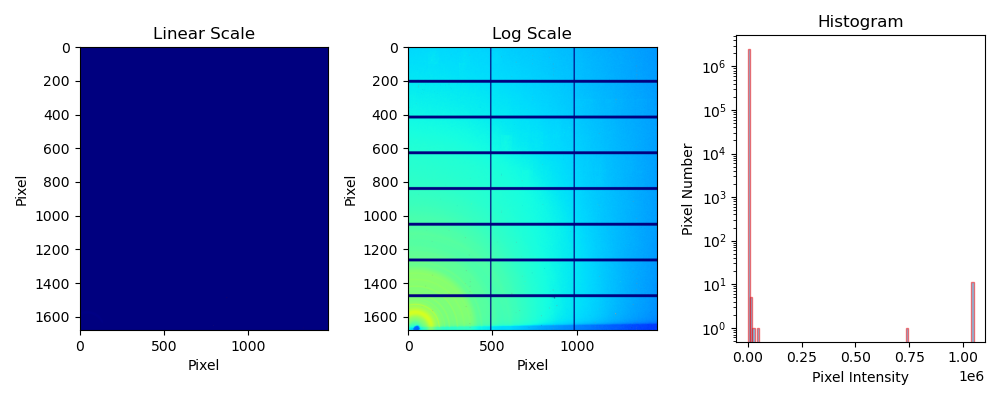

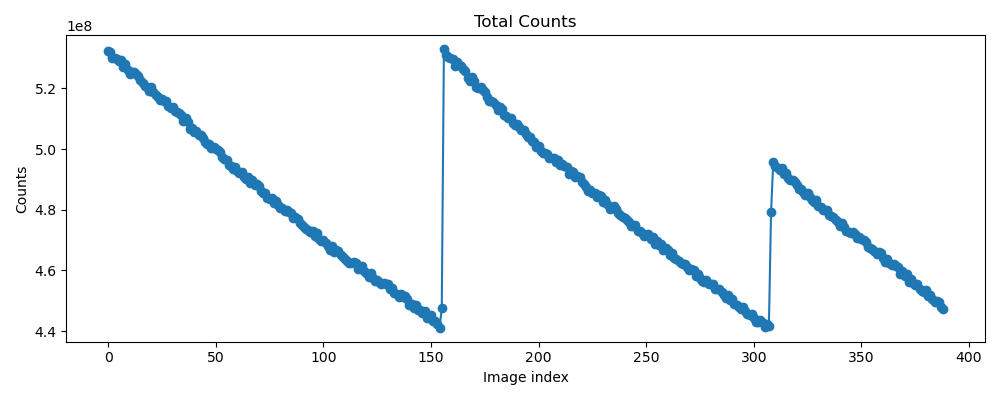

dict_keys(['images', 'counts', 'file_names', 'image_number', 'file_name', 'sample_name', 'fluence', 'delay'])
Images shape: (389, 1679, 1475)
Counts shape: (389,)
Fluences: [10.]
Delays: [-8.e-08 -2.e-09  1.e-09  1.e-08  2.e-07]


In [4]:
data_dict = trxrd.get_image_details(
    folder_path=DATA_PATH,
    sample_name=SCAN_NAME,
    filename_scheme="delay_scan",
    sort_key="image_number",
    plot=True,
)
print(data_dict.keys())
print("Images shape:", data_dict["images"].shape)
print("Counts shape:", data_dict["counts"].shape)

if SCAN_TYPE == "theta_samz":
    print("Degrees:", np.unique(data_dict["degree"]))
    print("Theta:", np.unique(data_dict["theta"]))
    print("Samz:", np.unique(data_dict["samz"]))
elif SCAN_TYPE == "delay_scan":
    print("Fluences:", np.unique(data_dict["fluence"]))
    print("Delays:", np.unique(data_dict["delay"]))

## Remove Images Based on Total Counts

0 images removed from 389 initial images


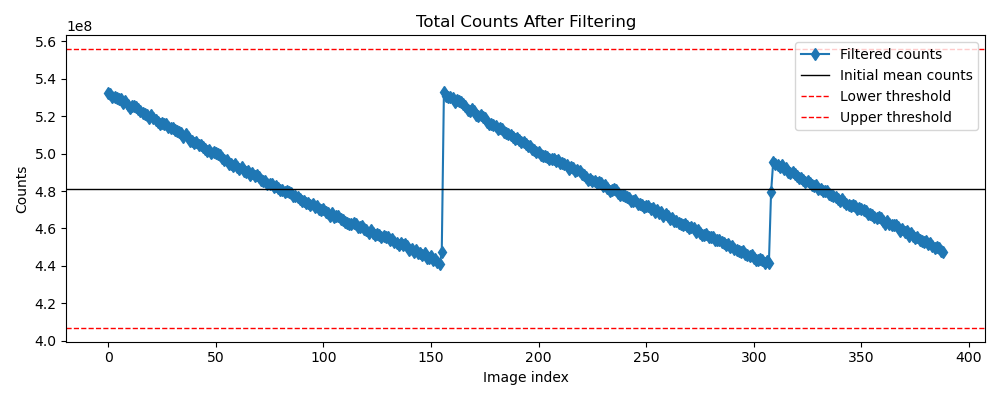

Clean images shape: (389, 1679, 1475)
Removed images: 0


In [ ]:
count_result = trxrd.remove_counts(
    data_dict,
    std_factor=STD_FACTOR,
    added_range=None,   # e.g. [[10, 20]]
    plot=True,
    return_dict=True,
)

data_dict = count_result["filtered_data"]

print("Clean images shape:", data_dict["images"].shape)
print("Removed images:", count_result["n_removed"])

## Build Combined Masks

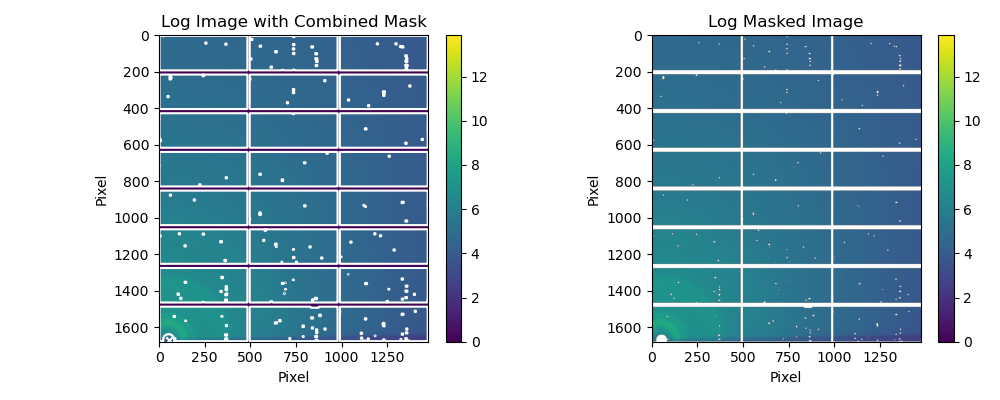

In [5]:
image_shape = data_dict["images"].shape[1:]   # (rows, cols)

combined_mask = trxrd.build_combined_mask(
    image_shape,
    center_xy = (MASK_CENTER_X, MASK_CENTER_Y),
    radius = MASK_RADIUS,
    detector_mask=None,
    mask_path=MASK_FILE,
    plot=True,
    example_image=data_dict["images"][0],
)

## Compute Azimuthal Average

Using PONI geometry from file: C:\Users\lheald\Documents\Guzelturk_Lab\Cotts_Processed_Data\CeO2\low_keV\CeO2_poni.poni
Integrating 389 images...
  Completed 100/389 (25.7%)
  Completed 200/389 (51.4%)
  Completed 300/389 (77.1%)
  Completed 389/389 (100.0%)
Done integrating.
q shape: (3000,)
profiles shape: (389, 3000)


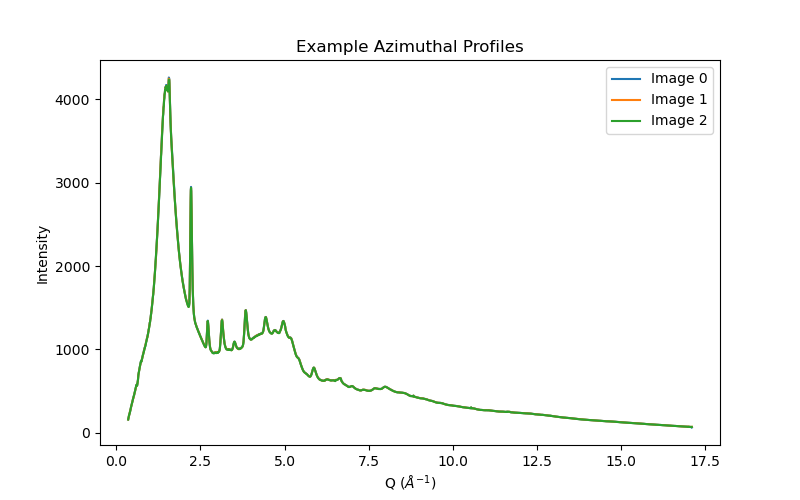

In [6]:
if PONI_FILE is not None:
    print(f"Using PONI geometry from file: {PONI_FILE}")
    az_result = trxrd.azimuthal_average_pyfai(
    images=data_dict["images"],
    centers_xy=None,   # note: (x, y)
    poni_path=PONI_FILE,
    npt=N_POINTS,
    unit=UNIT,
    nan_radial_range=(NAN_MIN, NAN_MAX),   # set Q < 0.3 to NaN
    azimuth_range=None,
    integration_mask=combined_mask,
    return_dict=True,
    progress_interval=100,
    use_custom_polarization=False,
    integration_function="integrate1d",
    correct_solid_angle=False,
    method=("bbox", "csr", "cython")
)
else:
    print("Using manual geometry parameters.")
    az_result = trxrd.azimuthal_average_pyfai(
        images=data_dict["images"],
        centers_xy=(CENTER_X, CENTER_Y),   # note: (x, y)
        polarization_factor=POLARIZATION_FACTOR,
        npt=N_POINTS,
        unit=UNIT,
        nan_radial_range=(NAN_MIN, NAN_MAX),   # set Q < 0.3 to NaN
        azimuth_range=None,
        integration_mask=combined_mask,
        return_dict=True,
        progress_interval=100,
        use_custom_polarization=False,
        integration_function="integrate1d",
        correct_solid_angle=False,
        method=("bbox", "csr", "cython")
    )

q = az_result["radial"]
profiles = az_result["profiles"]

print("q shape:", q.shape)
print("profiles shape:", profiles.shape)

plt.figure(figsize=(8, 5))
for i in [0, 1, 2]:
    plt.plot(q, profiles[i], label=f"Image {i}")
plt.xlabel(r"Q ($\AA^{-1}$)")
plt.ylabel("Intensity")
plt.title("Example Azimuthal Profiles")
plt.legend()
plt.show()

## Normalize Azimuthal Averages

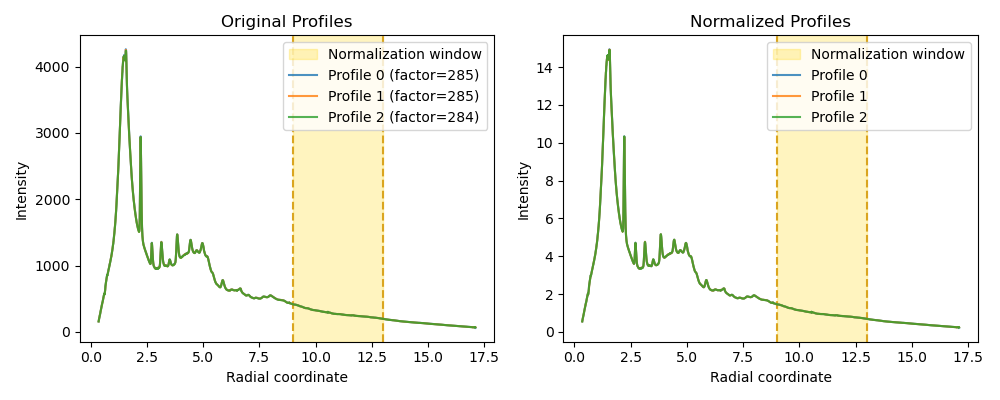

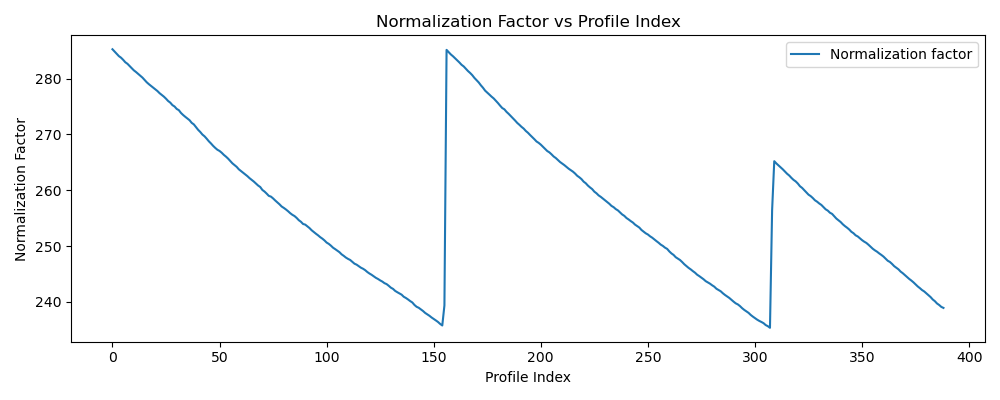

In [7]:
norm_result = trxrd.normalize_profiles_to_range(
    radial=q,
    profiles=profiles,
    norm_range=(9, 13),   # example
    mode="mean",
    plot=True,
    plot_indices=[0, 1, 2],
    show_normalized_plot=True,
    return_dict=True,
    plot_factors=True,
)

profiles_norm = norm_result["normalized_profiles"]

## Load and Prepare Background Image(s)

**Make sure you're treating the background and the data the same! i.e., same masks, same centers, etc**

dict_keys(['files', 'background_stack', 'background_mean', 'background_std', 'n_images'])
Background stack shape: (1, 1679, 1475)
Background mean shape: (1679, 1475)
Integrating 1 images...


C:\Users\lheald\AppData\Local\Temp\ipykernel_32932\1336029795.py:21: RuntimeWarning: Mean of empty slice
  bg_dict["background_mean"] = np.nanmean(bg_dict["background_stack"], axis=0)


  Completed 1/1 (100.0%)
Done integrating.


c:\Users\lheald\Documents\Guzelturk_Lab\trxrd\trxrd\normalization.py:266: RuntimeWarning: Mean of empty slice
  background_profile_mean = np.nanmean(background_profiles, axis=0)
c:\Users\lheald\AppData\Local\miniconda3\envs\research\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


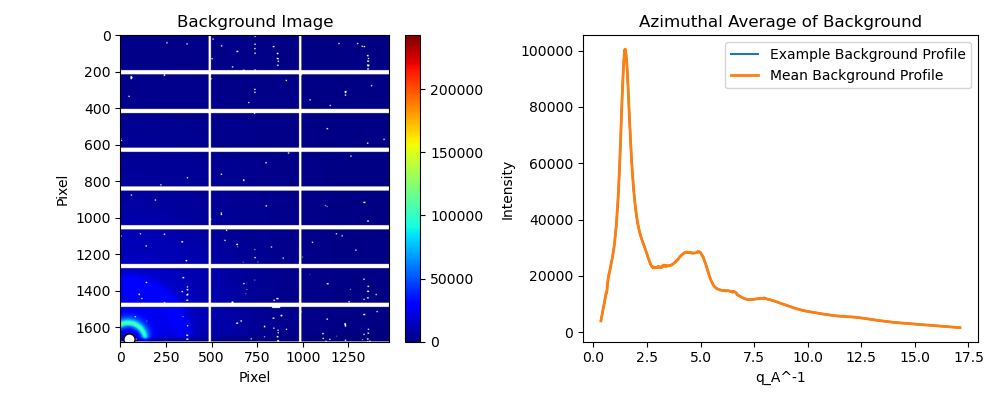

In [8]:
# Background path can be either:
# - a single tif file
# - or a folder containing many background tif files
# Load Data
bg_dict = trxrd.load_background(
    background_path=BACKGROUND_PATH,
    sort=True,
    plot=False,
)

print(bg_dict.keys())
print("Background stack shape:", bg_dict["background_stack"].shape)
print("Background mean shape:", bg_dict["background_mean"].shape)

bg_dict["background_stack"] = trxrd.apply_mask_from_bool(
    data_array=bg_dict["background_stack"],
    mask_bool=combined_mask,
)


bg_dict["background_mean"] = np.nanmean(bg_dict["background_stack"], axis=0)


# Compute background azimuthal average
if PONI_FILE is not None:
    bg_az_result = trxrd.compute_background_azimuthal_average(
        background_input=bg_dict["background_stack"],
        centers_xy=None,   # one average center in (x, y)
        poni_path=PONI_FILE,
        npt=N_POINTS,
        unit=UNIT,
        nan_radial_range=(NAN_MIN, NAN_MAX),   # set Q < 0.3 to NaN
        azimuth_range=None,
        integration_mask=combined_mask,
        return_dict=True,
        progress_interval=100,
        use_custom_polarization=False,
        integration_function="integrate1d",
        correct_solid_angle=False,
        plot=True,
    )
else:
    bg_az_result = trxrd.compute_background_azimuthal_average(
        background_input=bg_dict["background_stack"],
        centers_xy=(CENTER_X, CENTER_Y),   # one average center in (x, y)
        unit=UNIT,
        polarization_factor=POLARIZATION_FACTOR,
        npt=N_POINTS,
        use_custom_polarization=False,
        integration_function="integrate1d",
        correct_solid_angle=False,
        plot=True,
    )

q_bg = bg_az_result["radial"]
background_profile = bg_az_result["background_profile_mean"]



## Subtract Scaled Background from Images

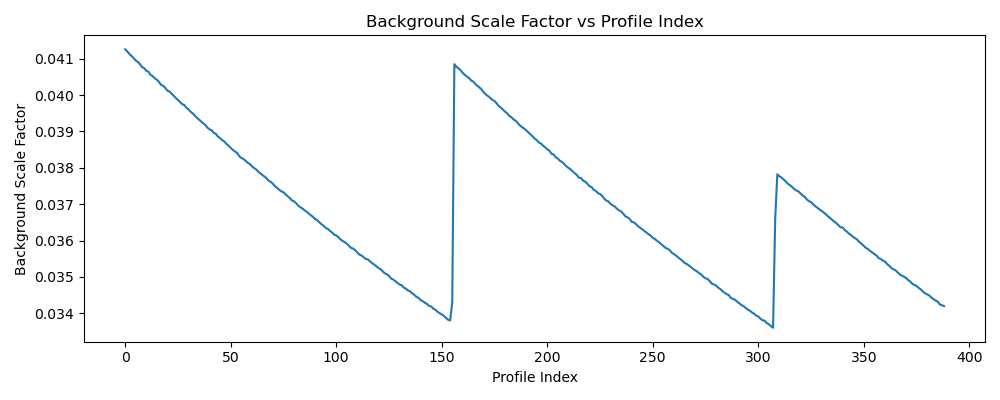

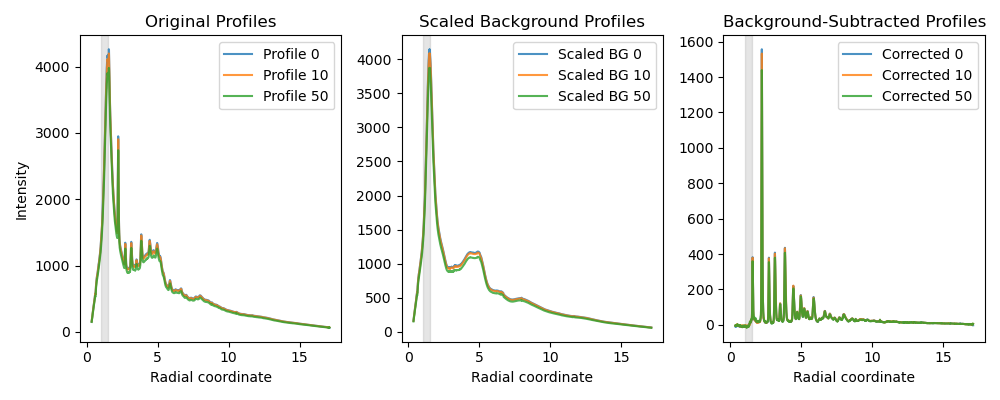

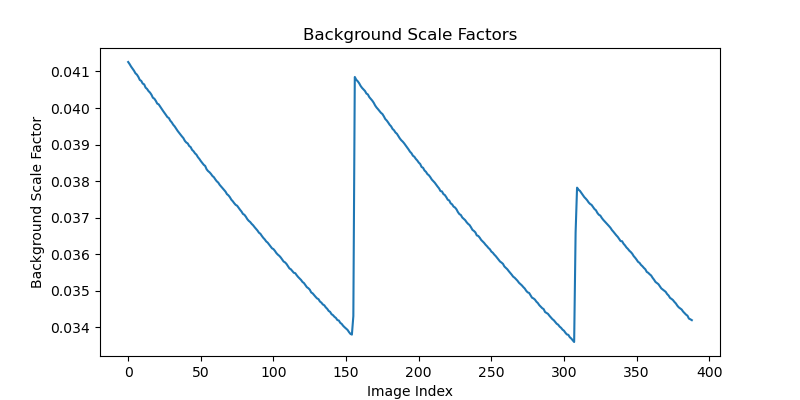

In [9]:
bgsub_result = trxrd.subtract_scaled_background_profile(
    radial=q,
    profiles=profiles,
    background_profile=background_profile,
    norm_range=(1.0, 1.5),   # example region; adjust as needed
    mode="mean",
    scale_method="ratio",
    plot=True,
    plot_scale_factors=True,
    plot_indices=[0, 10, 50],
    return_dict=True,
)

profiles_bgsub = bgsub_result["corrected_profiles"]
baselines = bgsub_result["scaled_background_profiles"]

# Inspect Scaling Factors
plt.figure(figsize=(8, 4))
plt.plot(bgsub_result["scale_factors"])
plt.xlabel("Image Index")
plt.ylabel("Background Scale Factor")
plt.title("Background Scale Factors")
plt.show()

## Check Drifts with SVD

dict_keys(['U', 'S', 'Vt', 'variance_explained', 'reconstruction', 'axis_values', 'time_values'])
Singular values (dI): [55365.48432544  4248.63435979   237.20372322   122.26595183
   114.19796625]
Variance explained: [9.93964734e-01 5.85317465e-03 1.82446599e-05 4.84734394e-06
 4.22872563e-06]


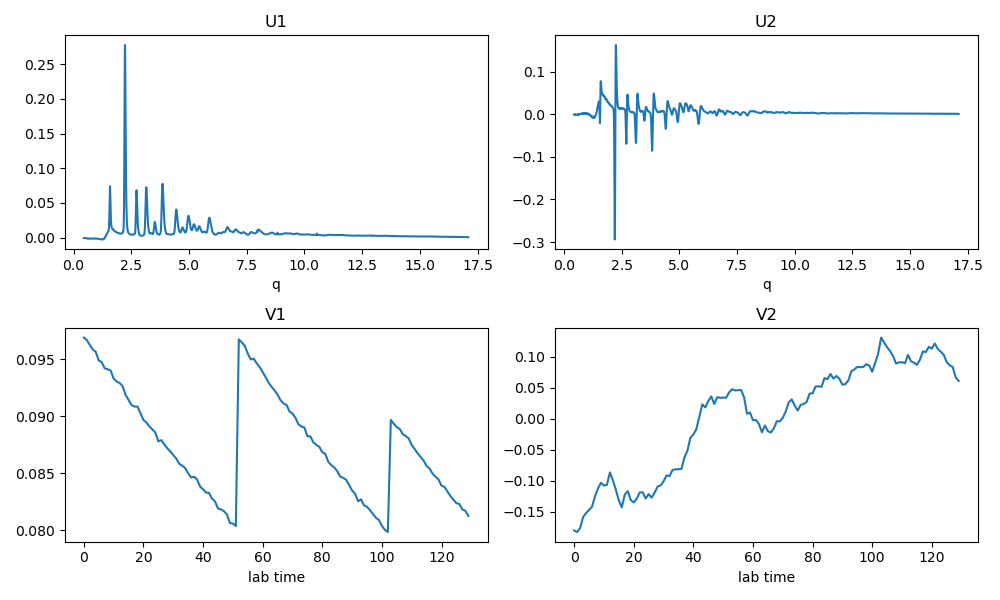

In [10]:
matrix = profiles_bgsub.T  # shape (n_q, n_delays)

svd_dict = trxrd.svd_analysis(
    data=matrix[20:, ::3], 
    axis_values=q[20:],
    time_values=data_dict["delay"][::3]
)
print(svd_dict.keys())

# Inspect
print("Singular values (dI):", svd_dict['S'][:5])
print("Variance explained:", svd_dict['variance_explained'][:5])

# Plot first two components

fig, axes = plt.subplots(2, 2, figsize=(10, 6))
for i in range(2):
    axes[0, i].plot(q[20:], svd_dict['U'][:, i])
    axes[0, i].set_xlabel('q'); axes[0, i].set_title(f'U{i+1}')
    axes[1, i].plot(svd_dict['Vt'][i, :])
    axes[1, i].set_xlabel('lab time'); axes[1, i].set_title(f'V{i+1}')
plt.tight_layout()

## Track and Correct Peak Drift

c:\Users\lheald\Documents\Guzelturk_Lab\trxrd\trxrd\analysis.py:1605: RuntimeWarning: Mean of empty slice
  I_ref = np.nanmean(I_stack, axis=1)


Detected 6 peak(s) at q = [1.576633   2.22541137 2.72318098 3.14824266 3.8529502  4.44579939]


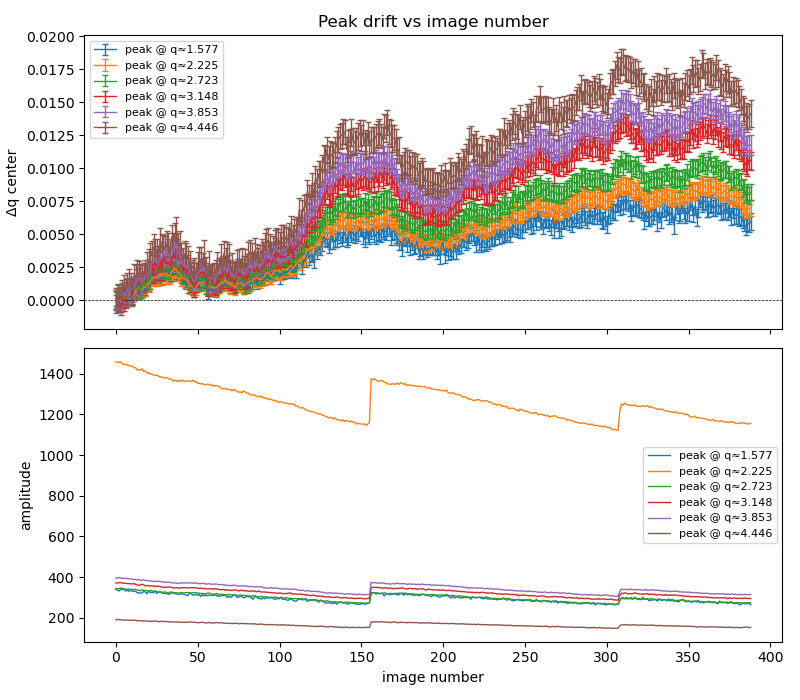

In [11]:
# q: (Nq,), I_stack: (Nq, Nimg)
results = trxrd.track_peaks(
    q, profiles_bgsub.T,
    ref="mean",          # average pattern is more robust than image 0
    prominence=150,      # <-- tune this; main knob for detection
    distance=1,          # min samples between peaks
)

fig, axes = trxrd.plot_drift(results, relative=True)
plt.show()

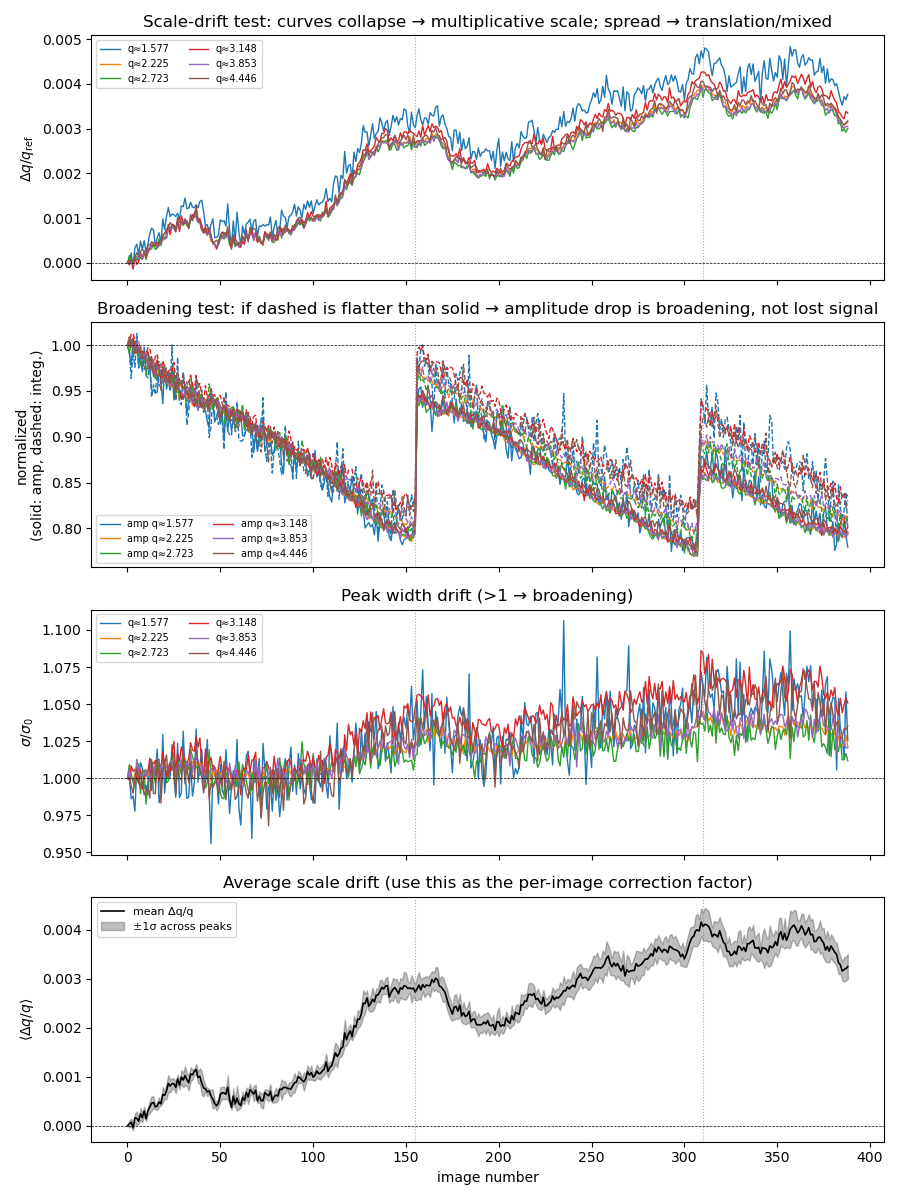

In [12]:
fig, axes = trxrd.plot_diagnostics(
    results,
    topup_images=[155, 310],   # mark the top-up events
)
plt.show()

# If panel 1 shows clean collapse, you can use:
s = trxrd.scale_drift_factor(results)
# then for each image j, resample I_stack[:, j] from q onto q * (1 + s[j])
# (or equivalently, redefine q_corrected = q / (1 + s[j]) per image)

## Apply q Correction 

In [ ]:


# Step 2: apply correction
q_corr, I_corr = trxrd.apply_scale_correction(q, profiles_bgsub.T, s, kind="cubic")

# Step 3: verify by re-running peak tracking on corrected data
results_corr, summary = trxrd.verify_correction(
    q_corr, I_corr, results,
    track_peaks_fn=trxrd.track_peaks,
    prominence=150,    # same as your original call
)

Trimmed 15 q points to avoid extrapolation.
Output q range: [0.3350, 17.0243]
Detected 6 peak(s) at q = [1.57104009 2.21981845 2.71758806 3.14264975 3.84176436 4.44020648]
    Peak q     Before (pp)      After (pp)   Reduction
-------------------------------------------------------
     1.577        4.92e-03        6.38e-04       87.0%
     2.225        4.02e-03        6.28e-04       84.4%
     2.723        3.95e-03        7.58e-04       80.8%
     3.148        4.41e-03        6.30e-04       85.7%
     3.853        3.99e-03        7.10e-04       82.2%
     4.446        4.07e-03        8.08e-04       80.1%


In [41]:
I_corr.shape

(2985, 389)

dict_keys(['U', 'S', 'Vt', 'variance_explained', 'reconstruction', 'axis_values', 'time_values'])
Singular values (dI): [0.87111295 0.03274502 0.00429957 0.00256552 0.00184797]
Variance explained: [9.98390111e-01 1.41072313e-03 2.43220755e-05 8.65966969e-06
 4.49306770e-06]


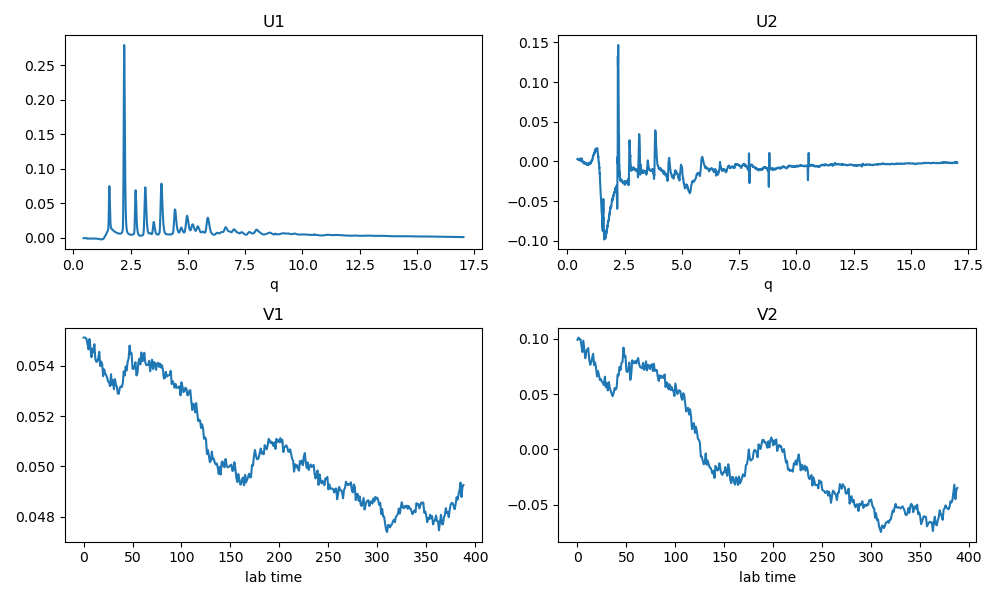

In [44]:
norm_per_image = np.nansum(I_corr, axis=0)
I_corr_norm = I_corr / norm_per_image
matrix = I_corr_norm  # shape (n_q, n_delays)

svd_dict = trxrd.svd_analysis(
    data=matrix[20:, :], 
    axis_values=q_corr[20:],
    time_values=data_dict["delay"]
)
print(svd_dict.keys())

# Inspect
print("Singular values (dI):", svd_dict['S'][:5])
print("Variance explained:", svd_dict['variance_explained'][:5])

# Plot first two components

fig, axes = plt.subplots(2, 2, figsize=(10, 6))
for i in range(2):
    axes[0, i].plot(q_corr[20:], svd_dict['U'][:, i])
    axes[0, i].set_xlabel('q'); axes[0, i].set_title(f'U{i+1}')
    axes[1, i].plot(svd_dict['Vt'][i, :])
    axes[1, i].set_xlabel('lab time'); axes[1, i].set_title(f'V{i+1}')
plt.tight_layout()

# Check Drift in G(r)

## Define Path and Scan Name

In [13]:
DATA_PATH = Path(r"C:\Users\lheald\Documents\Guzelturk_Lab\Cotts_Processed_Data\BTO400nmS3_360Kre4\repo\output")
SCAN_NAME = "BTO400nmS3_360Kre4"

## Load the Data

In [14]:
# Main diffraction data folder
data_path = DATA_PATH

# Check number of files in folder 
file_names = sorted(data_path.glob(f"{SCAN_NAME}*.gr"))
print(f"{len(file_names)} TIFF files found in {data_path}.")

389 TIFF files found in C:\Users\lheald\Documents\Guzelturk_Lab\Cotts_Processed_Data\BTO400nmS3_360Kre4\repo\output.


394 .gr files found in C:\Users\lheald\Documents\Guzelturk_Lab\Cotts_Processed_Data\BTO400nmS3_360Kre4\repo\output


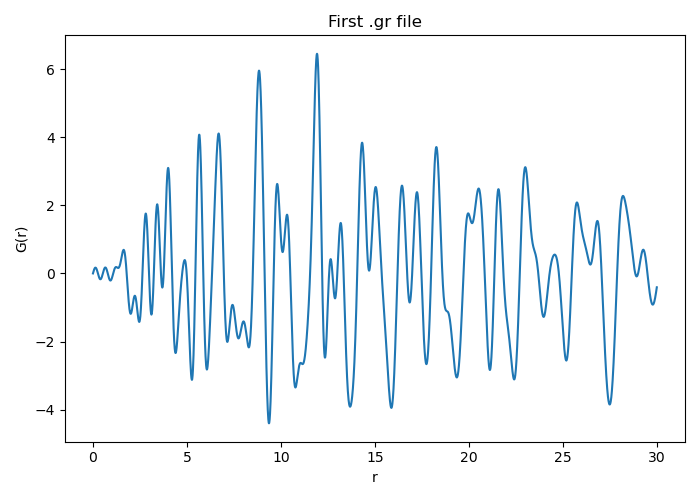

In [15]:
gr_dict = trxrd.get_gr_details(
    folder_path=DATA_PATH,
    sample_name=SCAN_NAME,
    filename_scheme="delay_scan",
    sort=True,
    filter_data=False,
    delay_sign=-1,
    plot=True,
)

r = gr_dict["r"]           # shape (Nr,)
grs = gr_dict["grs"]       # shape (Nfiles, Nr)
delay = gr_dict["delay"]   # shape (Nfiles,)

# gr_dict = trxrd.get_grs_by_scan_name(
#     folder_path=DATA_PATH)

## Check Drifts with SVD

dict_keys(['U', 'S', 'Vt', 'variance_explained', 'reconstruction', 'axis_values', 'time_values'])
Singular values (dI): [2071.27588334  185.62311132    9.22162291    8.34182473    8.01659204]
Variance explained: [9.91524892e-01 7.96327695e-03 1.96536149e-05 1.60823625e-05
 1.48527644e-05]


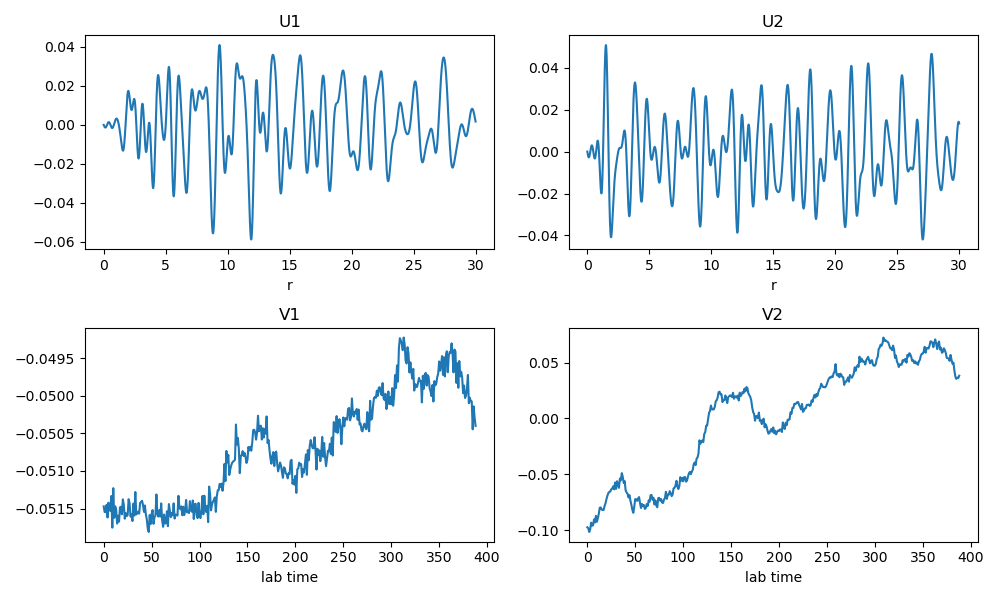

In [16]:
matrix = grs.T  # shape (n_q, n_delays)

svd_dict = trxrd.svd_analysis(
    data=matrix, 
    axis_values=r,
    time_values=delay
)
print(svd_dict.keys())

# Inspect
print("Singular values (dI):", svd_dict['S'][:5])
print("Variance explained:", svd_dict['variance_explained'][:5])

# Plot first two components

fig, axes = plt.subplots(2, 2, figsize=(10, 6))
for i in range(2):
    axes[0, i].plot(r, svd_dict['U'][:, i])
    axes[0, i].set_xlabel('r'); axes[0, i].set_title(f'U{i+1}')
    axes[1, i].plot(svd_dict['Vt'][i, :])
    axes[1, i].set_xlabel('lab time'); axes[1, i].set_title(f'V{i+1}')
plt.tight_layout()

## Track and Correct Peak Drift

Detected 4 peak(s) at q = [ 8.82 11.9  14.29 18.23]


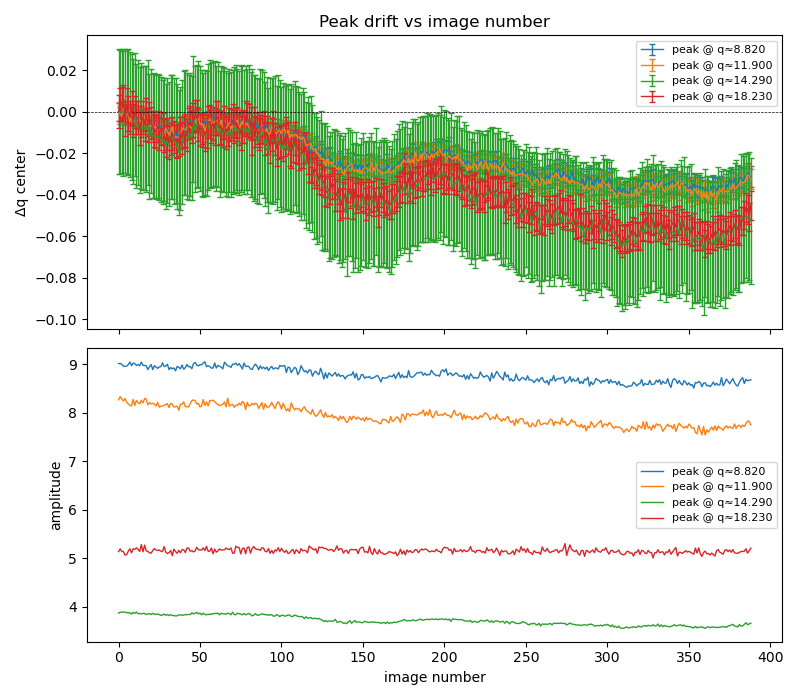

In [17]:
# q: (Nq,), I_stack: (Nq, Nimg)
results = trxrd.track_peaks(
    r, grs.T,
    ref="mean",          # average pattern is more robust than image 0
    prominence=7,      # <-- tune this; main knob for detection
    distance=5,          # min samples between peaks
)

fig, axes = trxrd.plot_drift(results, relative=True)
plt.show()

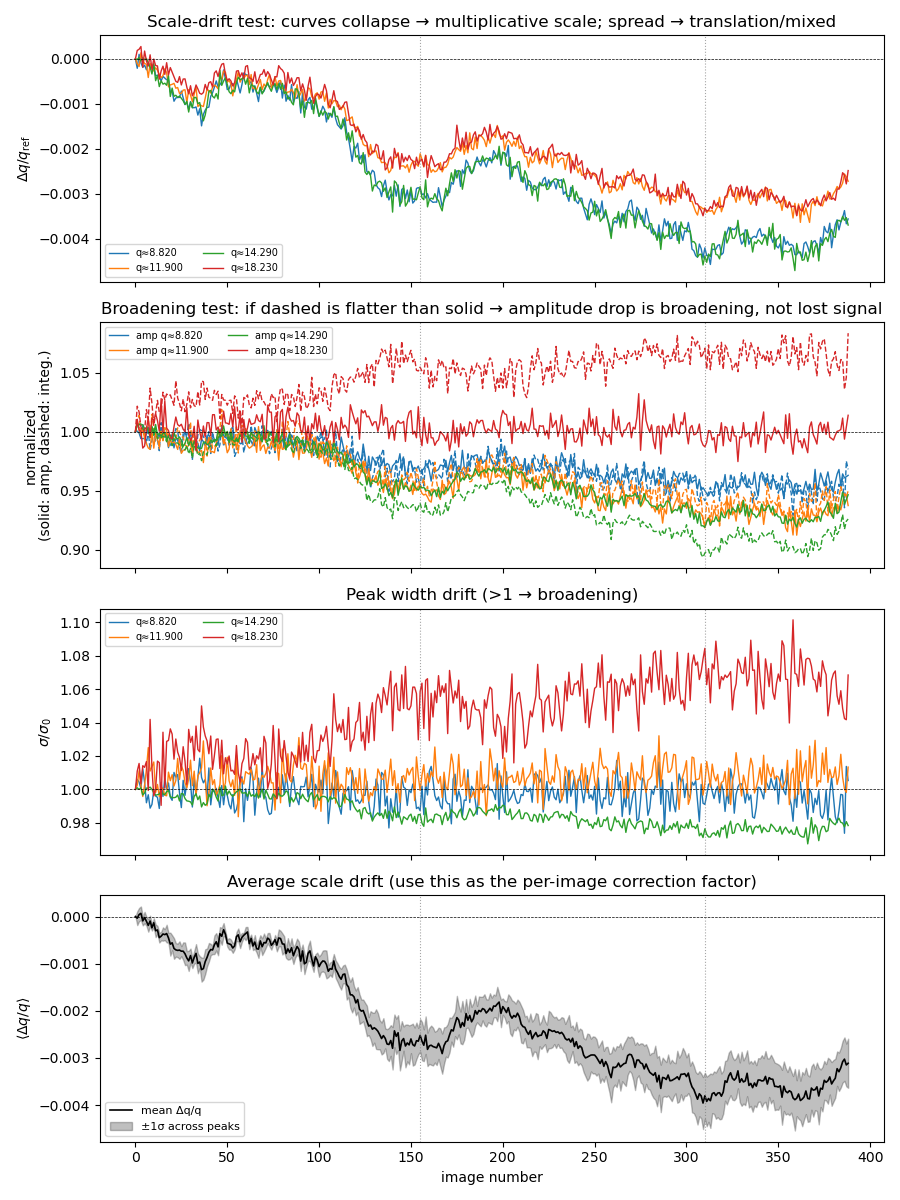

In [18]:
fig, axes = trxrd.plot_diagnostics(
    results,
    topup_images=[155, 310],   # mark the top-up events
)
plt.show()

# If panel 1 shows clean collapse, you can use:
s = trxrd.scale_drift_factor(results)
# then for each image j, resample I_stack[:, j] from q onto q * (1 + s[j])
# (or equivalently, redefine q_corrected = q / (1 + s[j]) per image)

In [20]:
# ------------------------------------------------------------
# Apply q drift correction
# ------------------------------------------------------------

s = trxrd.scale_drift_factor(results)
# Step 2: apply correction
r_corr, Gr_corr = trxrd.apply_scale_correction(r, grs.T, s, kind="cubic")

# Step 3: verify by re-running peak tracking on corrected data
results_corr, summary = trxrd.verify_correction(
    r_corr, Gr_corr, results,
    track_peaks_fn=trxrd.track_peaks,
    prominence=7,    # same as your original call
)


Trimmed 1 q points to avoid extrapolation.
Output q range: [0.0000, 29.9900]
Detected 4 peak(s) at q = [ 8.84 11.93 14.32 18.28]
    Peak q     Before (pp)      After (pp)   Reduction
-------------------------------------------------------
     8.820        4.67e-03        6.39e-04       86.3%
    11.900        3.77e-03        9.29e-04       75.3%
    14.290        4.73e-03        9.81e-04       79.3%
    18.230        3.76e-03        9.65e-04       74.3%


In [23]:
avg_gr_dict = trxrd.average_profiles_by_delay(Gr_corr.T, delay, return_dict=True)
delays = np.unique(delay)*1e9


for i, profile in enumerate(avg_gr_dict["mean_profiles"]):
    np.savetxt(DATA_PATH/f"BaTiO3_{delays[i]}_new.gr", np.column_stack((r_corr, profile)), header="r\tg(r)")


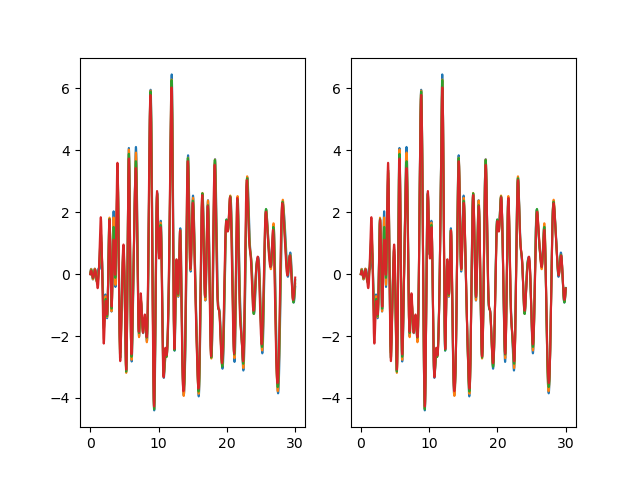

In [24]:
plt.figure()
plt.subplot(1,2,1)
plt.plot(r, grs[0])
plt.plot(r, grs[100])
plt.plot(r, grs[200])
plt.plot(r, grs[300])

plt.subplot(1,2,2)
plt.plot(r_corr, Gr_corr[:, 0])
plt.plot(r_corr, Gr_corr[:, 100])
plt.plot(r_corr, Gr_corr[:, 200])
plt.plot(r_corr, Gr_corr[:, 300])
plt.show()
